In [73]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler,Normalizer,OneHotEncoder,LabelEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression,Lasso,Ridge,ElasticNet
from sklearn.neighbors import KNeighborsClassifier 
from mlxtend.plotting import plot_decision_regions
from sklearn.ensemble import BaggingRegressor,BaggingClassifier,AdaBoostClassifier,AdaBoostRegressor,GradientBoostingRegressor,GradientBoostingClassifier,RandomForestClassifier,RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier,plot_tree

import xgboost as xgb

from sklearn.metrics import root_mean_squared_error,mean_squared_error,mean_absolute_error,r2_score,recall_score,confusion_matrix,classification_report,accuracy_score

In [74]:
df =pd.read_csv("/Users/prathamsharma/Desktop/ML_Dataset/gld_price_data.csv")

In [75]:
df.head(5)

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [76]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [77]:
df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [78]:
df.shape

(2290, 6)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


              SPX       GLD       USO       SLV   EUR/USD
SPX      1.000000  0.049345 -0.591573 -0.274055 -0.672017
GLD      0.049345  1.000000 -0.186360  0.866632 -0.024375
USO     -0.591573 -0.186360  1.000000  0.167547  0.829317
SLV     -0.274055  0.866632  0.167547  1.000000  0.321631
EUR/USD -0.672017 -0.024375  0.829317  0.321631  1.000000


<Axes: >

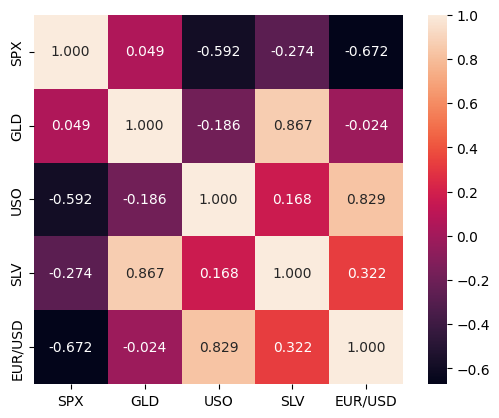

In [80]:
df1 = df.drop("Date",axis = 1)
correlation = df1.corr()

print(correlation)
sns.heatmap(correlation,annot=True,square=True,fmt=".3f")

In [81]:
correlation["GLD"]

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64

/var/folders/km/pql1mrbj65jbf346hp94yd3h0000gn/T/ipykernel_5825/2193262130.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["GLD"])


<Axes: xlabel='GLD', ylabel='Density'>

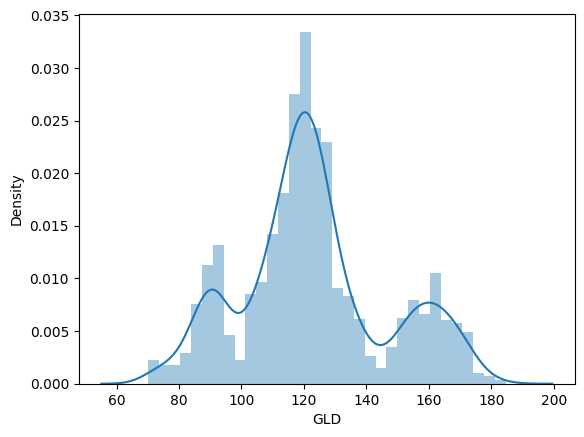

In [82]:
sns.distplot(df["GLD"])

In [83]:
x = df.drop(["GLD","Date"], axis =1)

y= df["GLD"]

print(x.shape,y.shape)

(2290, 4) (2290,)


In [84]:
print(x.head(), y.head())

           SPX        USO     SLV   EUR/USD
0  1447.160034  78.470001  15.180  1.471692
1  1447.160034  78.370003  15.285  1.474491
2  1411.630005  77.309998  15.167  1.475492
3  1416.180054  75.500000  15.053  1.468299
4  1390.189941  76.059998  15.590  1.557099 0    84.860001
1    85.570000
2    85.129997
3    84.769997
4    86.779999
Name: GLD, dtype: float64


In [85]:
x_train , x_test ,y_train , y_test = train_test_split( x , y , test_size=0.2 , random_state=42 )

regression = RandomForestRegressor(n_estimators=100)

regression.fit(x_train,y_train)

y_pred = regression.predict(x_test)

rmse = root_mean_squared_error( y_test , y_pred )
r2 = r2_score( y_test , y_pred )

In [86]:
print("RMSE:",rmse)
print("R2 SCORE:",r2)

RMSE: 2.4053245047802583
R2 SCORE: 0.9894481359215439
